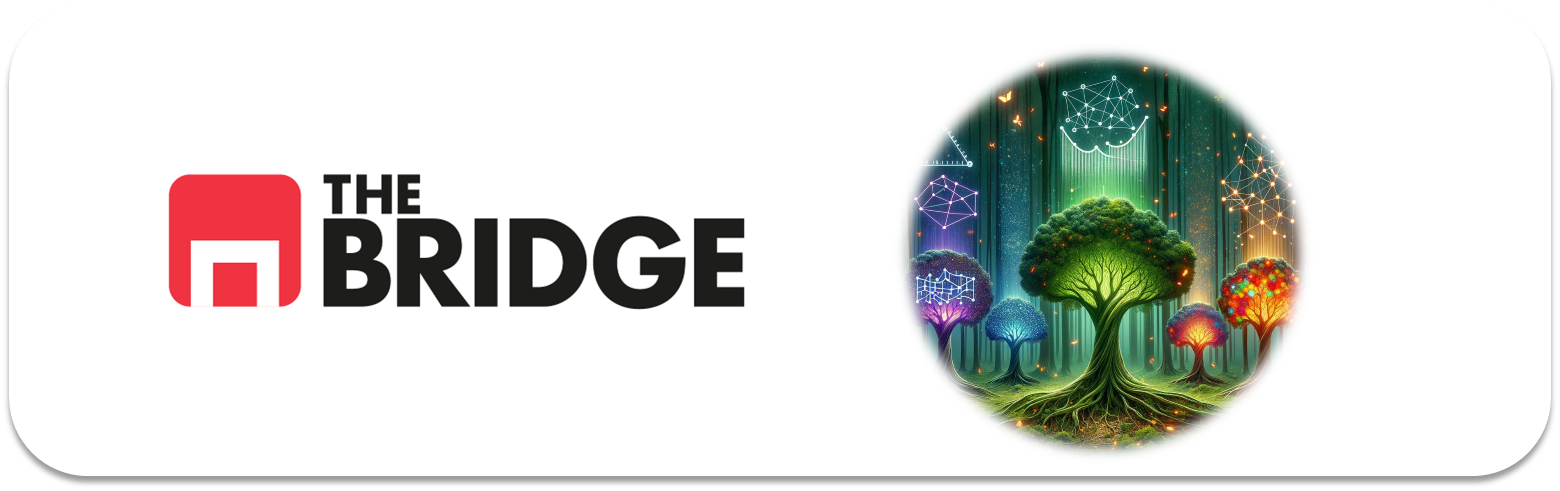

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
# Librerías básicas
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from bootcampviztools import (
    pinta_distribucion_categoricas,
    plot_combined_graphs,
    plot_grouped_boxplots,
)

# Preprocesado y split
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos: bagging y boosting
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay,
)

pd.set_option("display.max_columns", None)
np.random.seed(42)
SEED = 42

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [ ]:
df = pd.read_csv(url, names=names)
print(df.shape)
df.head()

(768, 9)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Ejercicio 1: Exploración inicial de los datos (EDA)

In [ ]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
plas,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
pres,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
test,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
mass,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
pedi,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


No hay `NaN` explícitos, pero varias variables tienen un mínimo de **0**, algo fisiológicamente imposible para magnitudes como la glucosa, la presión arterial, el pliegue cutáneo, la insulina o el índice de masa corporal (sí tiene sentido, en cambio, para `preg`, el número de embarazos). Es un problema conocido de este dataset: el 0 se usó como código para "dato no registrado". Vamos a cuantificarlo antes de decidir cómo tratarlo.

In [ ]:
cols_con_ceros_invalidos = ["plas", "pres", "skin", "test", "mass"]

for c in cols_con_ceros_invalidos:
    n_zeros = (df[c] == 0).sum()
    print(f"{c}: {n_zeros} ceros ({n_zeros/len(df):.1%})")

plas: 5 ceros (0.7%)
pres: 35 ceros (4.6%)
skin: 227 ceros (29.6%)
test: 374 ceros (48.7%)
mass: 11 ceros (1.4%)


`skin` (grosor del pliegue cutáneo) e `test` (insulina) tienen una proporción muy alta de ceros (~30% y ~49% respectivamente), lo trataremos como valores faltantes (`NaN`) más adelante, en la fase de limpieza.

Veamos ahora el target:

class
0    500
1    268
Name: count, dtype: int64
class
0    0.651042
1    0.348958
Name: proportion, dtype: float64


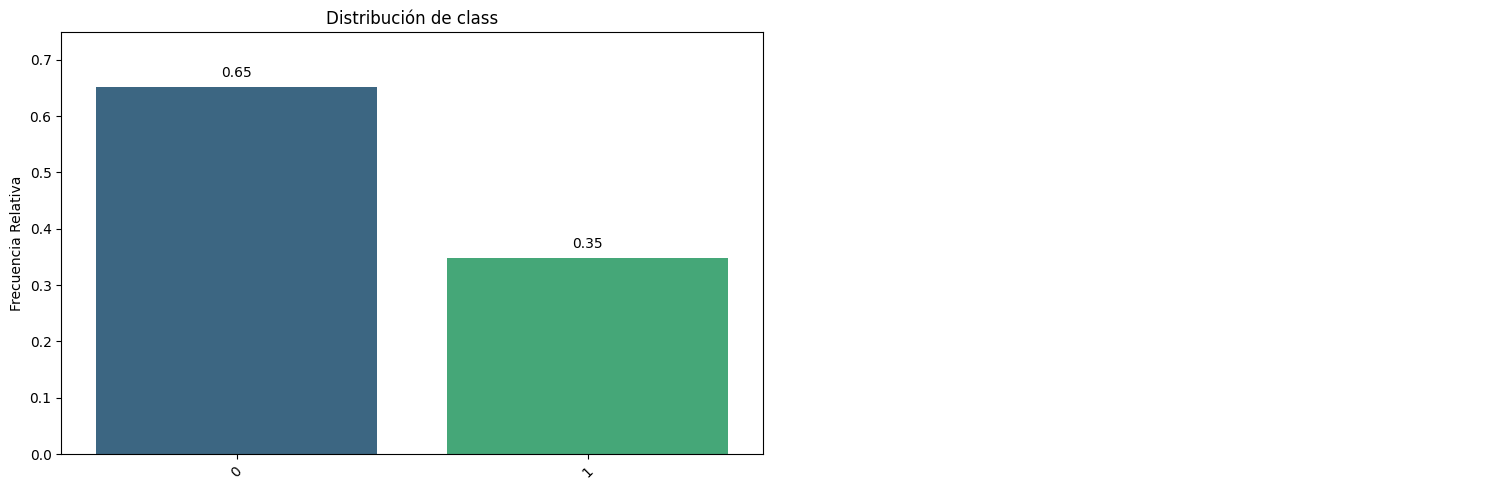

In [ ]:
print(df["class"].value_counts())
print(df["class"].value_counts(normalize=True))

pinta_distribucion_categoricas(df, ["class"], relativa=True, mostrar_valores=True)

El target está moderadamente desbalanceado (~65% no diabetes / ~35% diabetes). No es un desbalanceo extremo, pero sí lo suficiente como para no fiarnos solo del accuracy: usaremos **ROC-AUC** como métrica principal de comparación y optimización, y estratificaremos el split.

Distribución de las variables numéricas:

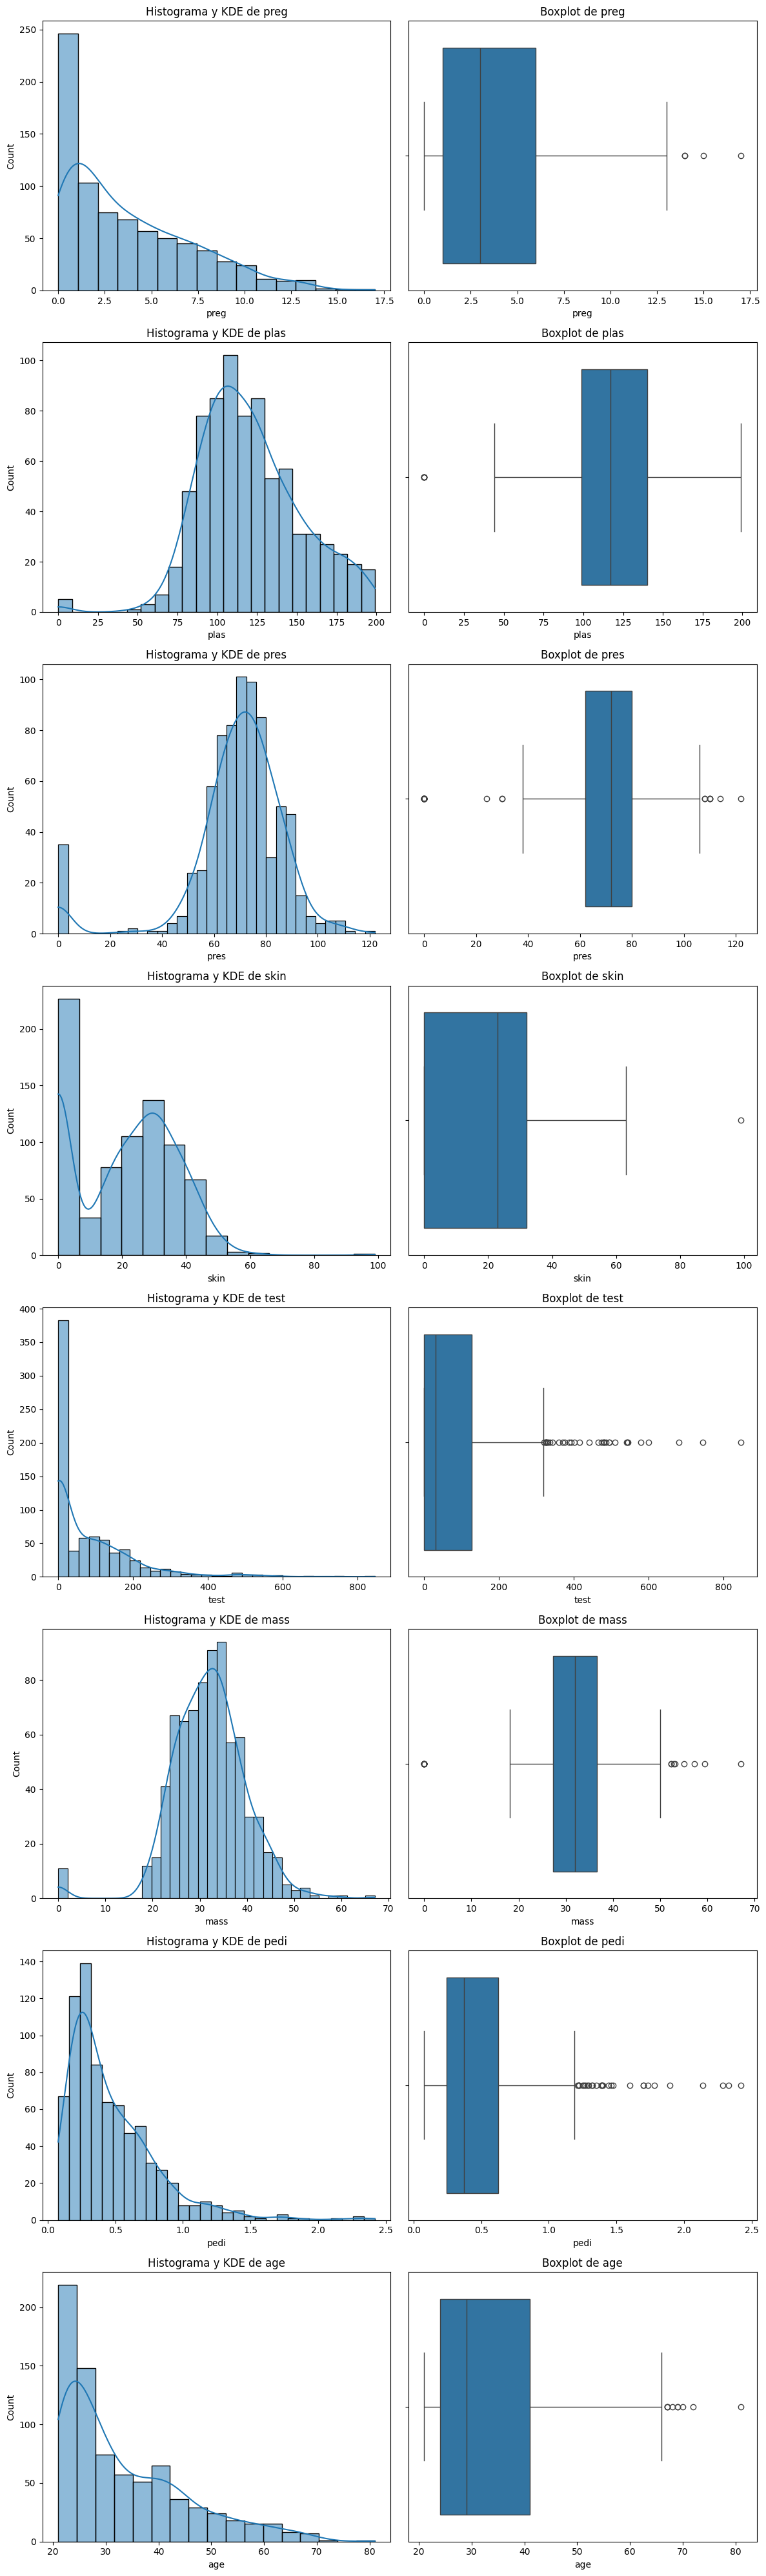

In [ ]:
plot_combined_graphs(df, ["preg", "plas", "pres", "skin", "test", "mass", "pedi", "age"])

Relación de algunas variables clave con el target (antes de limpiar los ceros, solo para hacernos una idea):

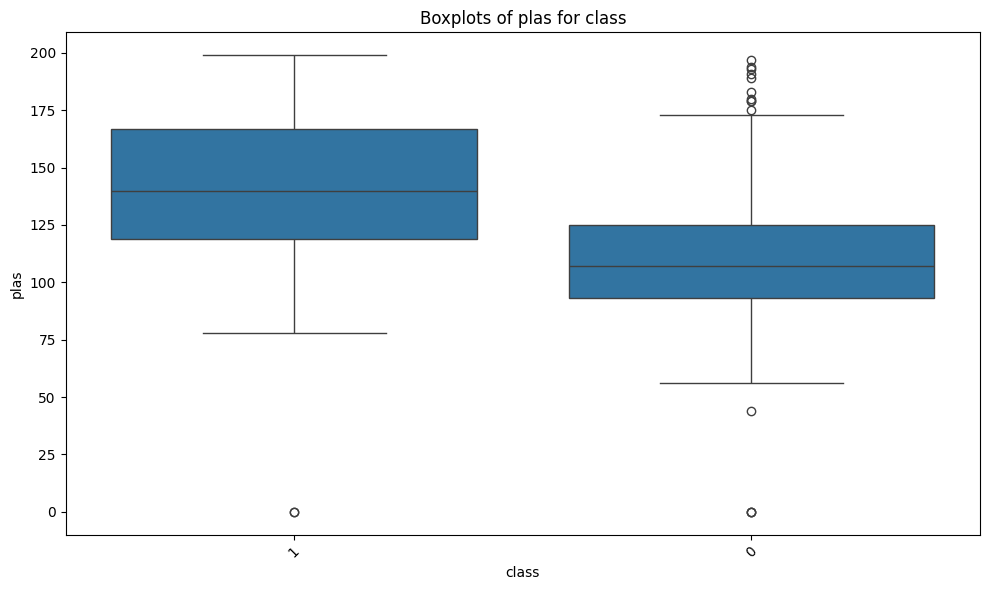

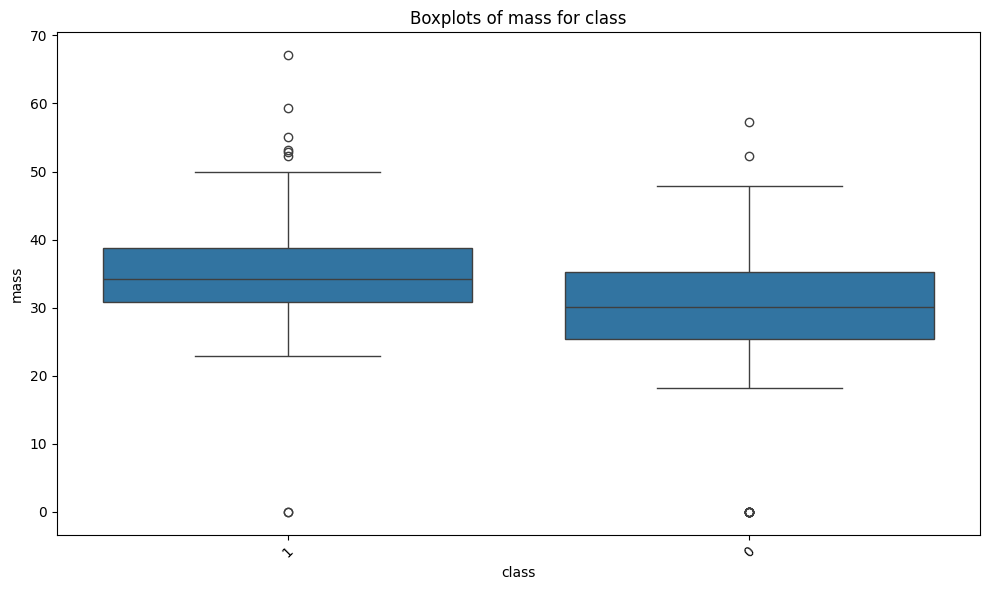

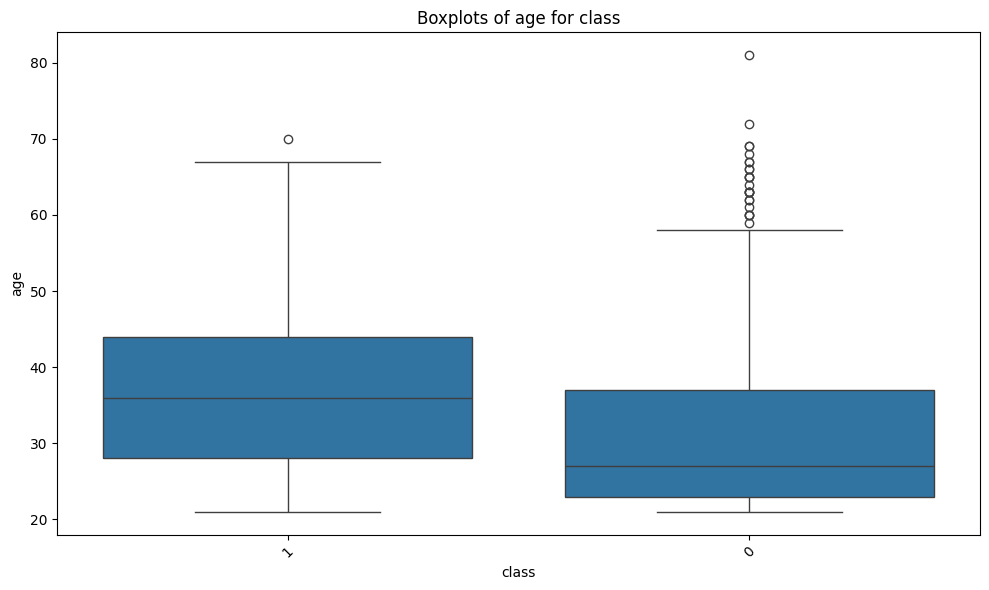

In [ ]:
plot_grouped_boxplots(df, "class", "plas")
plot_grouped_boxplots(df, "class", "mass")
plot_grouped_boxplots(df, "class", "age")

Se aprecia una diferencia clara en `plas` (glucosa en plasma) entre pacientes con y sin diabetes, tal y como cabría esperar clínicamente: es de esperar que sea una de las variables más influyentes en el modelo final.

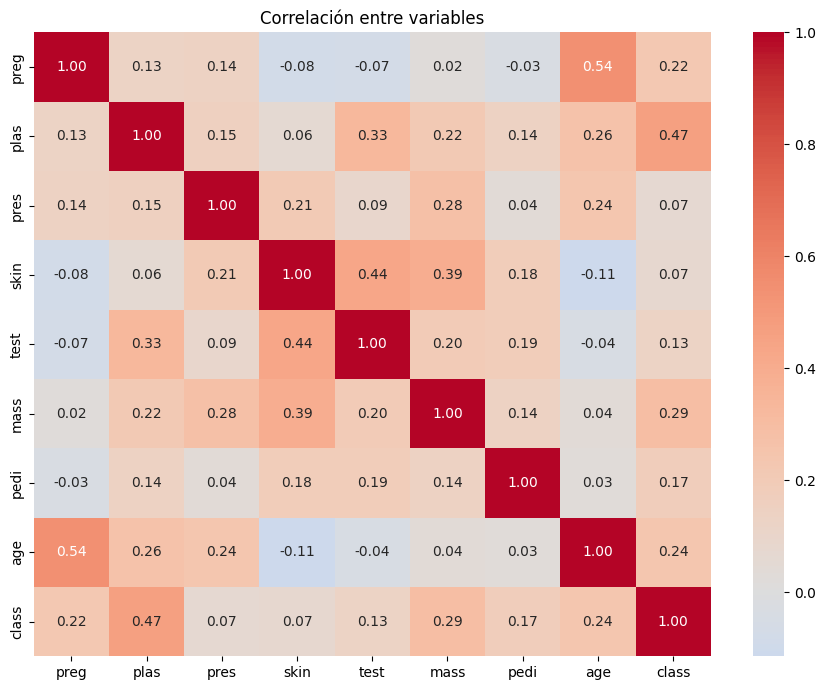

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

No hay correlaciones tan fuertes entre predictoras como para plantearnos eliminar alguna por colinealidad.

### Ejercicio 2: Limpieza y tratamiento

Sustituimos los ceros imposibles por `NaN` en `plas`, `pres`, `skin`, `test` y `mass`. La imputación (mediana) la haremos **dentro de un `Pipeline`**, ajustada solo con datos de train en cada fold/split, para no filtrar información de test ni de validación al entrenamiento (data leakage). Usamos la mediana en lugar de la media por ser más robusta a los outliers que vimos en los boxplots/histogramas.

In [ ]:
df_clean = df.copy()
for c in cols_con_ceros_invalidos:
    df_clean[c] = df_clean[c].replace(0, np.nan)

df_clean.isna().sum()

preg       0
plas       5
pres      35
skin     227
test     374
mass      11
pedi       0
age        0
class      0
dtype: int64

In [ ]:
X = df_clean.drop(columns=["class"])
y = df_clean["class"]

X.head()

,preg,plas,pres,skin,test,mass,pedi,age
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


### Ejercicio 3: Train / Test split

Reservamos el conjunto de test **ahora**, antes de comparar u optimizar ningún modelo, tal y como pide el enunciado. Usamos `stratify=y` por el desbalanceo del target.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Proporción positivos train:", y_train.mean().round(3))
print("Proporción positivos test :", y_test.mean().round(3))

Train: (614, 8)  Test: (154, 8)
Proporción positivos train: 0.349
Proporción positivos test : 0.351


### Ejercicio 4: Modelos de Bagging y Boosting

Elegimos 4 modelos, con al menos uno de bagging y al menos uno de boosting (el enunciado pide un mínimo de 3, con al menos uno de cada familia):

- **Random Forest** (`RandomForestClassifier`) — **bagging**: entrena muchos árboles en paralelo sobre submuestras (bootstrap) y agrega su voto.
- **AdaBoost** (`AdaBoostClassifier`) — **boosting**: entrena árboles en secuencia, dando más peso a las observaciones mal clasificadas por el anterior.
- **Gradient Boosting** (`GradientBoostingClassifier`) — **boosting**: cada árbol nuevo corrige los residuos del ensamblado anterior.
- **XGBoost** (`XGBClassifier`) — **boosting**: versión optimizada y regularizada de gradient boosting.

Todos los modelos se meten en un `Pipeline` junto con el `SimpleImputer` para que la imputación de los `NaN` se calcule correctamente en cada fold de validación cruzada.

In [ ]:
def make_pipe(clf):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", clf),
    ])

models = {
    "RandomForest (bagging)": make_pipe(RandomForestClassifier(random_state=SEED)),
    "AdaBoost (boosting)": make_pipe(AdaBoostClassifier(random_state=SEED)),
    "GradientBoosting (boosting)": make_pipe(GradientBoostingClassifier(random_state=SEED)),
    "XGBoost (boosting)": make_pipe(XGBClassifier(random_state=SEED, eval_metric="logloss")),
}

### Ejercicio 5: Comparación de modelos (validación cruzada, sin tocar test)

Comparamos los 4 modelos con validación cruzada estratificada (`cv=5`) **únicamente sobre train**, usando ROC-AUC como métrica (más informativa que accuracy dado el desbalanceo). El conjunto de test no se toca en ningún momento de esta comparación.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados_cv = {}
for nombre, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    resultados_cv[nombre] = scores
    print(f"{nombre:32s} ROC-AUC medio: {scores.mean():.4f}  (+/- {scores.std():.4f})")

ganador = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
print("\nGanador (mayor ROC-AUC medio en CV):", ganador)

RandomForest (bagging)           ROC-AUC medio: 0.8163  (+/- 0.0220)
AdaBoost (boosting)              ROC-AUC medio: 0.8184  (+/- 0.0171)


GradientBoosting (boosting)      ROC-AUC medio: 0.8194  (+/- 0.0161)
XGBoost (boosting)               ROC-AUC medio: 0.7787  (+/- 0.0260)

Ganador (mayor ROC-AUC medio en CV): GradientBoosting (boosting)


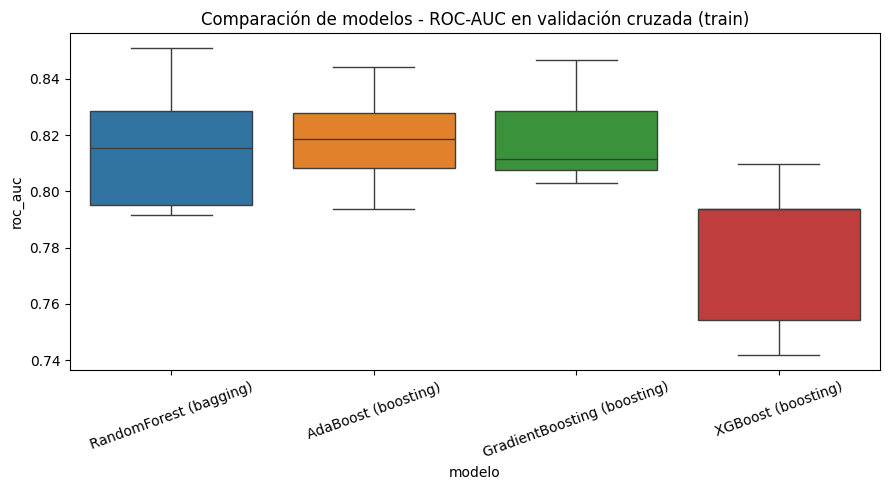

In [ ]:
resumen_cv = pd.DataFrame({k: v for k, v in resultados_cv.items()}).melt(var_name="modelo", value_name="roc_auc")

plt.figure(figsize=(9, 5))
sns.boxplot(data=resumen_cv, x="modelo", y="roc_auc", hue="modelo", legend=False)
plt.xticks(rotation=20)
plt.title("Comparación de modelos - ROC-AUC en validación cruzada (train)")
plt.tight_layout()
plt.show()

Los cuatro modelos quedan bastante cerca entre sí (algo esperable con solo 768 filas: la varianza entre folds no es pequeña), pero **el ganador según la media de ROC-AUC en CV se elige automáticamente arriba** y es con el que seguimos el resto del ejercicio. Random Forest (bagging) suele quedar muy cerca también, lo cual tiene sentido: con tan pocos datos, un método de boosting no tiene tanta ventaja relativa como en datasets más grandes, donde suele destacar más.

### Ejercicio 6: Optimización de hiperparámetros del modelo ganador

Definimos un grid de hiperparámetros razonado para cada modelo candidato (usamos el del `ganador` calculado arriba, sea cual sea):

- **`n_estimators`**: número de árboles del ensamblado. Más árboles no sobreajusta en bagging, pero sí puede hacerlo en boosting si además `learning_rate` es alto.
- **`learning_rate`** (solo boosting): cuánto aporta cada nuevo árbol. Valores bajos generalizan mejor pero necesitan más árboles para converger.
- **`max_depth`** / **`min_samples_leaf`**: controlan la complejidad de cada árbol individual y por tanto el riesgo de overfitting.
- **`max_features`** (Random Forest): cuántas variables se consideran en cada split, para decorrelacionar los árboles.
- **`subsample`** / **`colsample_bytree`** (Gradient Boosting / XGBoost): fracción de filas/columnas usada en cada árbol, similar en espíritu al bootstrap de bagging, ayuda a reducir varianza.

Usamos `RandomizedSearchCV` (más rápido que probar el grid completo) con `cv=5` y `scoring="roc_auc"`.

In [ ]:
param_grids = {
    "RandomForest (bagging)": {
        "clf__n_estimators": [100, 300, 500],
        "clf__max_depth": [2, 4, 8, None],
        "clf__max_features": ["sqrt", "log2", None],
        "clf__min_samples_leaf": [1, 5, 10],
        "clf__class_weight": [None, "balanced"],
    },
    "AdaBoost (boosting)": {
        "clf__n_estimators": [50, 100, 200, 400],
        "clf__learning_rate": [0.01, 0.1, 0.5, 1.0],
    },
    "GradientBoosting (boosting)": {
        "clf__n_estimators": [100, 200, 400],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__max_depth": [2, 3, 4],
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "XGBoost (boosting)": {
        "clf__n_estimators": [100, 200, 400],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__max_depth": [2, 3, 4, 6],
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0],
    },
}

search = RandomizedSearchCV(
    models[ganador],
    param_distributions=param_grids[ganador],
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    random_state=SEED,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Mejores hiperparámetros:", search.best_params_)
print("Mejor ROC-AUC en CV (train):", round(search.best_score_, 4))
print("ROC-AUC antes de optimizar :", round(resultados_cv[ganador].mean(), 4))

Mejores hiperparámetros: {'clf__subsample': 0.8, 'clf__n_estimators': 100, 'clf__min_samples_leaf': 1, 'clf__max_depth': 2, 'clf__learning_rate': 0.05}
Mejor ROC-AUC en CV (train): 0.8383
ROC-AUC antes de optimizar : 0.8194


In [ ]:
best_model = search.best_estimator_

### Ejercicio 7: Evaluación final contra test (obligatorio)

Ahora sí usamos el conjunto de test, reservado desde el principio y no tocado hasta este momento, para evaluar el modelo ganador ya optimizado.

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics_final = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
pd.DataFrame([metrics_final], index=[f"{ganador} (optimizado)"]).round(4)

,accuracy,precision,recall,f1,roc_auc
GradientBoosting (boosting) (optimizado),0.7338,0.6444,0.537,0.5859,0.8204


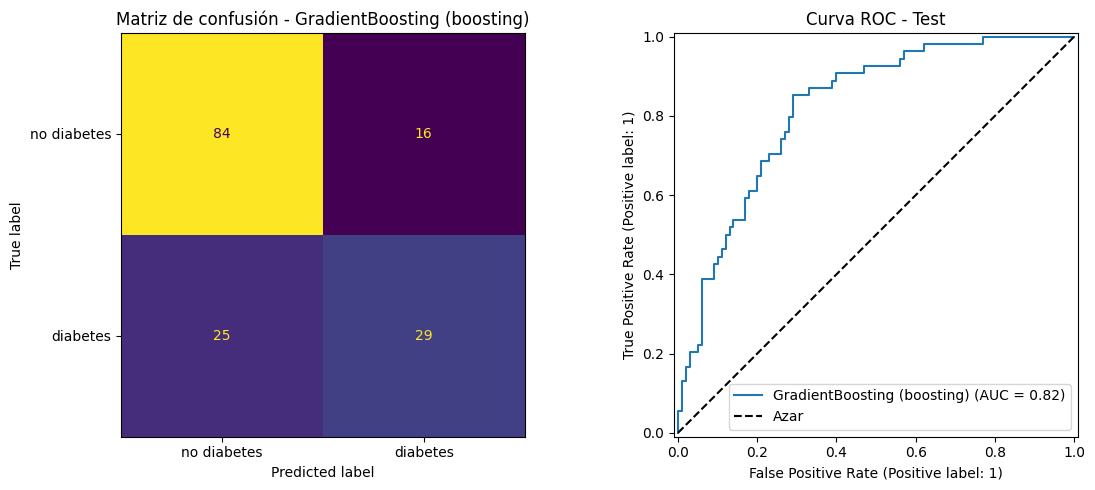

              precision    recall  f1-score   support

 no diabetes       0.77      0.84      0.80       100
    diabetes       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["no diabetes", "diabetes"], ax=axes[0], colorbar=False)
axes[0].set_title(f"Matriz de confusión - {ganador}")

RocCurveDisplay.from_predictions(y_test, y_proba, name=ganador, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="Azar")
axes[1].set_title("Curva ROC - Test")
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["no diabetes", "diabetes"]))

Importancia de variables según el modelo ganador (todos los candidatos de este notebook exponen `feature_importances_`):

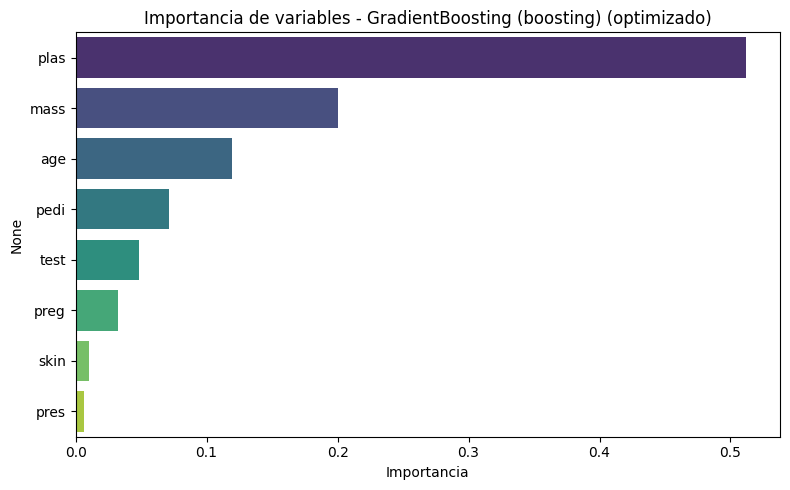

In [ ]:
importancias = pd.Series(
    best_model.named_steps["clf"].feature_importances_,
    index=X.columns,
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, legend=False, palette="viridis")
plt.title(f"Importancia de variables - {ganador} (optimizado)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

### Ejercicio 8: Valoración final

- **Comparación sin tocar test**: de los 4 modelos (Random Forest como bagging; AdaBoost, Gradient Boosting y XGBoost como boosting), la validación cruzada sobre train selecciona automáticamente al ganador impreso arriba. Con solo 768 filas las diferencias entre modelos son pequeñas y la desviación entre folds no es despreciable, así que no hay que sobreinterpretar diferencias de un par de puntos porcentuales entre ellos.
- **Optimización**: `RandomizedSearchCV` mejora el ROC-AUC en validación cruzada respecto al modelo sin optimizar del ganador (se compara explícitamente en el Ejercicio 6).
- **Test**: el modelo optimizado se evalúa una única vez contra test. El recall de la clase "diabetes" (la que más nos interesa detectar desde el punto de vista clínico/preventivo) es la métrica a la que prestaríamos más atención en un caso de uso real, más que el accuracy global.
- **Variables más influyentes**: como esperábamos por el EDA, la glucosa en plasma (`plas`) suele ser, junto con el IMC (`mass`) y la edad (`age`), de las variables con mayor peso en la predicción — coincide con el conocimiento clínico sobre factores de riesgo de diabetes tipo 2.
- **Limitaciones**: dataset pequeño (768 filas) y con bastantes ceros/valores faltantes reales en `skin` e `test` (insulina), que hemos imputado con la mediana por simplicidad; con más tiempo se podría probar una imputación más sofisticada (KNNImputer, imputación por grupos), técnicas de balanceo de clases (SMOTE, `class_weight`), o ampliar la búsqueda de hiperparámetros y el número de modelos candidatos (LightGBM, CatBoost, stacking de varios ensembles).